# Subset selection with k-medoids + genetic algorithm (GA, intelligrate.subset)

This notebook shows a full subsetting workflow using only the **Python API**:
1) compute a distance matrix
2) inspect k diagnostics
3) fit k-medoids
4) run a genetic algorithm (GA) to select a balanced subset

It uses the example data in `data/` and writes outputs to `results/subset/`.


## Install (pip)
If you are running this notebook outside the repo, install with pip.
If you are inside the cloned repo, no need to additionally install anything (except some dependencies if missing).




In [1]:
from pathlib import Path
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pwd

'/Users/meyeanni/Desktop/git_sourdough/Intelligrate/docs/notebooks'

install intelligrate (if not yet installed)

In [3]:
# Uncomment if needed:
# !pip install "intelligrate @ git+https://github.com/ORG/REPO.git@vX.Y.Z"



In [4]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists():
            return p
    raise FileNotFoundError('Could not find repo root (pyproject.toml)')

repo_root = find_repo_root(Path.cwd())

# Ensure local package imports work without installation
sys.path.insert(0, str(repo_root / 'src'))

results_dir = repo_root / 'results/HF_sourdough' / 'subset_100'
results_dir.mkdir(parents=True, exist_ok=True)

print('Repo root:', repo_root)
print('Results dir:', results_dir)


Repo root: /Users/meyeanni/Desktop/git_sourdough/Intelligrate
Results dir: /Users/meyeanni/Desktop/git_sourdough/Intelligrate/results/HF_sourdough/subset_100


## Load example inputs
- `feature_table_rel.tsv`: samples x features (relative abundances)
- `metadata.tsv`: sample metadata (includes latitude/longitude and categorical fields)


In [5]:
feature_table = pd.read_csv(repo_root / 'data/HF_sourdough' / 'feature_table_rel.tsv', sep='	', index_col=0)
metadata = pd.read_csv(repo_root / 'data/HF_sourdough' / 'metadata.tsv', sep='	', index_col=0)

print('Feature table:', feature_table.shape)
print('Metadata:', metadata.shape)
feature_table.head()


Feature table: (660, 1513)
Metadata: (660, 74)


,000374cc0b5094caadc10eca9249a15a,001980aad4ceeb8122ccbf4b4ccf2473,003042e64789c1c3d6a52c2c02a3bc6b,00bdfe8050e750ea895d8e2935cf597f,00d4e13e85b6a1fc2c6da6bf039a11f4,00d5aa4641ef6307754d3a12512c15b2,00fec325b5706470c228658864426461,014134a9578be6fc3ff85e77581c22de,02157aec7cec293b3d3d6e82bf15027f,0261a67a1590a45e03ce72557e4c60ea,...,fe8d1e67790b18f7c5b3fa1d13d4061c,feb1c288cd46f6fd9bc3c2c35970cbdf,fed0951be24d94017ed3ff2e62d09d7f,fef1349d7987b6e78162e639e25b52cd,fef758caabb2ba24d40654b913ef4fc8,ff0d424973b9da20d83b10d02bda65ec,ff2cc1d0ea5cd6df773325165ed1b5d7,ff9d93d7b7e46787568f2d241caeaf3b,ffce626fc5fd8bb0713685de606369b0,ffdd2d6be9d9ec3540012dea0c45d9fd
3ff35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38c2b,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2d683,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
65ba0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
622f9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 1. Distance matrix
Parameters explained in simple words:
- `metric`: how we define distance between samples (`bray`, `jaccard`, `aitchison`)
- `assume_relative`: set True if the table is already relative abundance
- `pseudocount`: only used for Aitchison/CLR (small number to avoid log(0))

We use Bray-Curtis here, which is common for relative abundance tables.


if not already installed in the current env, install deap:

In [7]:
#install deap:
! pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 631.7/631.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [deap]


In [6]:
from intelligrate.subset import compute_distance_matrix


metric = 'bray' #it is also possible to use 'jaccard' or 'aitchison'
assume_relative = True #only used for bray and jaccard, set to True if data is relative abundances
pseudocount = 1e-6 #only used for aitchison

D = compute_distance_matrix(
    feature_table,
    metric=metric,
    assume_relative=assume_relative,
    pseudocount=pseudocount,
)

# Save output
D.to_csv(results_dir / 'distance.tsv', sep='	')

print('Distance matrix shape:', D.shape)
D.iloc[:5, :5]


Distance matrix shape: (660, 660)


,3ff35,38c2b,2d683,65ba0,622f9
3ff35,0.000000,0.438124,0.80800,0.973500,0.934000
38c2b,0.438124,0.000000,0.80596,0.977444,0.940781
2d683,0.808000,0.805960,0.00000,0.988500,0.966000
65ba0,0.973500,0.977444,0.98850,0.000000,0.624000
622f9,0.934000,0.940781,0.96600,0.624000,0.000000


## Step 2. Choose k with diagnostics
Parameters explained:
- `k_range`: which k values to test
- `gap_B`: how many reference datasets to use for the gap statistic
- `random_state`: for reproducibility

We do not auto-pick k. Instead, we show diagnostics so you can choose.


In [ ]:
from intelligrate.subset import suggest_k


k_range = range(2, 30) #test k from 2 to 19
gap_B = 3 #number of bootstrap samples for gap statistic
random_state = 42

k_result = suggest_k(
    D,
    feature_table,
    k_range=k_range,
    gap_B=gap_B,
    random_state=random_state,
    return_fig=True,
)

kdiag = pd.DataFrame(
    {
        'k': k_result['k_values'],
        'silhouette': k_result['silhouette'],
        'davies_bouldin': k_result['davies_bouldin'],
        'gap': k_result['gap'],
        'gap_std': k_result['gap_std'],
    }
)

kdiag.to_csv(results_dir / 'k_diagnostics.tsv', sep='	', index=False)

# Plot the diagnostics (also saved below)
fig = k_result.get('figure')
#save as pdf:
fig.savefig(results_dir / 'k_diagnostics.pdf', bbox_inches='tight', dpi=300)
fig


<Figure size 800x1200 with 3 Axes>

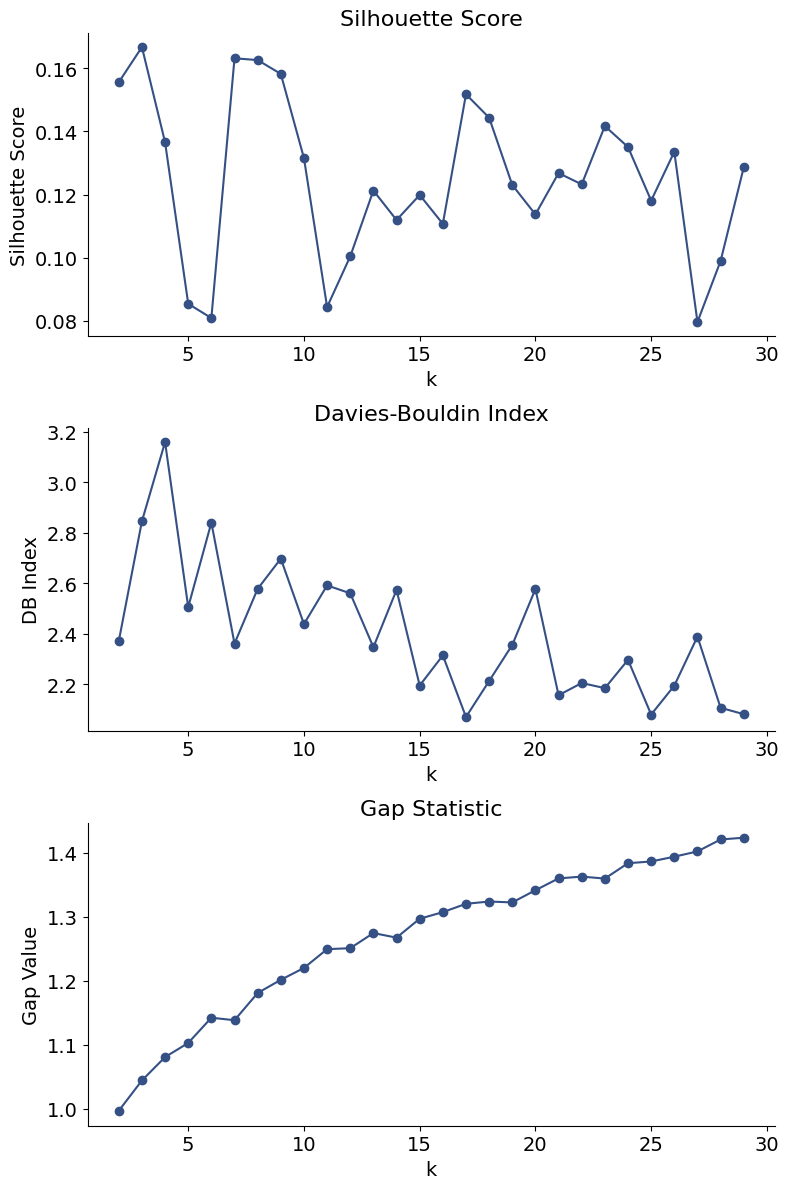

In [8]:
%matplotlib inline
fig

In [9]:
k_result

{'k_values': [2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 'silhouette': [0.15554131927866965,
  0.1666708502901762,
  0.13655827512980062,
  0.08544511443356016,
  0.08092738968671813,
  0.1631136736141098,
  0.16256323592959282,
  0.1581891950473011,
  0.13153343040595167,
  0.08441090160629725,
  0.10044475137845878,
  0.12127320167996176,
  0.11194722749460374,
  0.11987509648997632,
  0.11074888505563507,
  0.15172988443567956,
  0.1443282376556706,
  0.12303744576280287,
  0.11372177461218722,
  0.12680200370976966,
  0.12323368192314245,
  0.1416892112933546,
  0.1350329542846026,
  0.11808232666900968,
  0.13352944768306593,
  0.07968729557068044,
  0.09898746897150275,
  0.12859678961676377],
 'davies_bouldin': [2.370815560291199,
  2.8454868715315342,
  3.1588526306610882,
  2.5056216772701925,
  2.840111535553382,
  2.361269145623111,
  2.5776493263299485,
  2.6

## Step 3. Fit k-medoids
Parameters explained:
- `k`: number of clusters
- `random_state`: for reproducibility

K-medoids gives one representative "medoid" per cluster.


In [10]:
from intelligrate.subset import fit_kmedoids

k = 10 #for now we take 10 clusters, but this should be chosen based on the dataset specific diagnostics above!!!!
random_state = 42

kmed = fit_kmedoids(D, k=k, random_state=random_state)
clusters = kmed['cluster_df']
cluster_counts = kmed['cluster_counts']
medoids = kmed['medoid_samples']

clusters.to_csv(results_dir / 'kmedoids_clusters.tsv', sep='	')
pd.DataFrame({'cluster': cluster_counts.index, 'n': cluster_counts.values}).to_csv(
    results_dir / 'kmedoids_cluster_counts.tsv', sep='	', index=False
)

print('Clusters:', clusters.shape)
clusters.head()


Clusters: (660, 2)


,Cluster,Is_Medoid
Sample,,
3ff35,5,False
38c2b,7,False
2d683,5,False
65ba0,2,False
622f9,4,False


### Visualize clusters in 2D (MDS)
This is a quick 2D view of the distance matrix. It helps you see clustering structure.


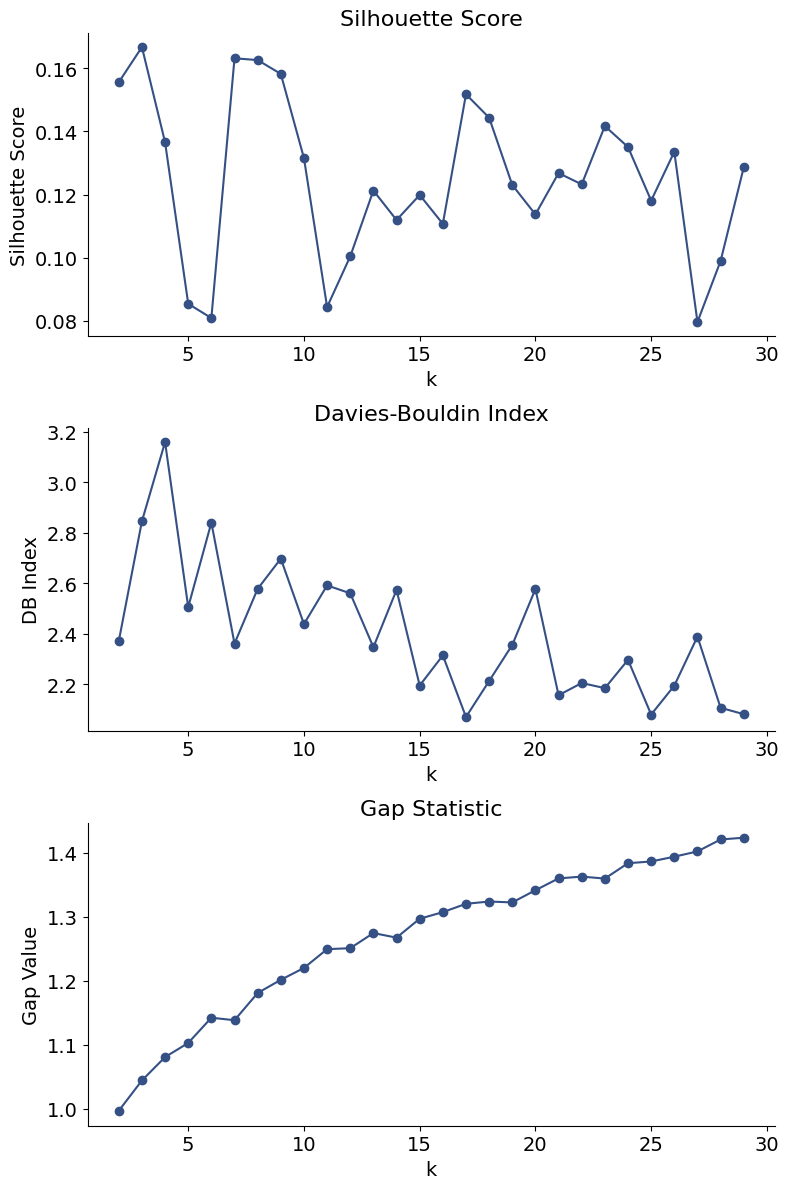

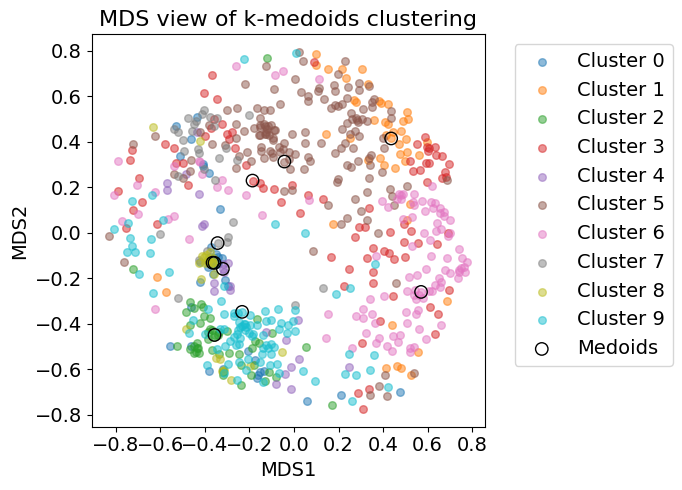

In [11]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(D.to_numpy(float))

plot_df = pd.DataFrame(coords, index=D.index, columns=['MDS1', 'MDS2'])
plot_df['Cluster'] = clusters['Cluster']
plot_df['Is_Medoid'] = clusters['Is_Medoid']

plt.figure(figsize=(7, 5))
for cl in sorted(plot_df['Cluster'].unique()):
    sub = plot_df[plot_df['Cluster'] == cl]
    plt.scatter(sub['MDS1'], sub['MDS2'], s=30, alpha=0.5, label=f'Cluster {cl}')

med = plot_df[plot_df['Is_Medoid']]
plt.scatter(med['MDS1'], med['MDS2'], s=80, facecolors='none', edgecolors='black', label='Medoids')

plt.title('MDS view of k-medoids clustering', fontsize=16)
plt.xlabel('MDS1', fontsize=14)
plt.ylabel('MDS2', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)
plt.tight_layout()
#save as pdf:
plt.savefig(results_dir / 'kmedoids_mds.pdf', bbox_inches='tight', dpi=300)
plt.show()


## Step 4. GA subset selection
Parameters explained:
- `total_samples`: how many samples to select
- `balance_vars`: categorical metadata fields to balance, if you have numeric variables too, consider binning them first
- `coord_vars`: columns for latitude/longitude
- `population_size`, `generations`: GA runtime/quality tradeoff -> meaning how many sample sets per iteration and how many iterations
- `grid_weight`, `distance_weight`, `balance_weight`: how much each goal matters, higher = more important
- `min_category_n`: ignore metadata categories (within a variable) with fewer than this many samples
- `min_per_category`: enforce a minimum in the selected set, e.g. at least 2 samples per category per variable
- `fixed_include` / `fixed_exclude`: force include or exclude IDs

If you want to see every parameter in the function signature, check:
- `src/intelligrate/subset/ga.py` (function `ga_subset`)


In [12]:
metadata.columns.to_list()

['sample_received_month',
 'latitude',
 'longitude',
 'elevation',
 'pH_laboratory',
 'tta_laboratory',
 'cfu_lab',
 'cfu_yeasts',
 'r_samp_source',
 'r_samp_country',
 'covid',
 'r_dough_source',
 'r_dough_stor_device',
 'r_dough_cover',
 'r_yeast_usage_prior',
 'r_flour_type_red_red',
 'r_flour_quality',
 'r_flour_organic',
 'r_flour_change',
 'r_water_type',
 'r_flour_additions',
 'r_backslop_freq',
 'r_refreshment_flour',
 'r_temp_feeding',
 'r_time_feeding',
 'r_stor_feeding',
 'r_dough_size_feeding',
 'r_temp_storage',
 'r_ph_value_citizen',
 'cat',
 'dog',
 'other_with_hair',
 'other_without_hair',
 'r_plants',
 'r_kids',
 'r_flour_comp_not_determ',
 'r_wheat',
 'r_semi_wholemeal_wheat',
 'r_wholemeal_wheat',
 'r_rye',
 'r_wholemeal_rye',
 'r_wholemeal_spelt',
 'r_spelt',
 'r_barley',
 'r_other_wheat_varieties',
 'r_gluten_free_flour',
 'p_number_sourdoughs',
 'p_after_feeding',
 'p_bread_making_frequency',
 'p_skill',
 'p_perceived_health_benefits',
 'p_alcoholic_beverage',
 'p

In [14]:
from intelligrate.subset import ga_subset

# Choose which metadata fields to balance
balance_vars = ['r_samp_country', 'r_samp_source', 'r_flour_type_red_red', 'r_flour_quality','cluster']
coord_vars = ('latitude', 'longitude')

# GA settings (smaller values run faster for this demo for generation and population sizes)
result_df, best_scores, fitness_array = ga_subset(
    cluster_df=clusters,
    metadata_df=metadata,
    total_samples=100,
    balance_vars=balance_vars,
    coord_vars=coord_vars,
    min_category_n=5,
    min_per_category=8,
    grid_size=2.5, #this is a large grid size to encourage more spread out samples, but this should be chosen based on the dataset specific diagnostics above!!!! (roughly 2.5x2.5 degree grid)
    population_size=2000,
    generations=100,
    random_state=42,
    fixed_include = ['vubh091', 'vubh077', 'vubh075', 'vubh076', 'ubzh106', 'ubzh035', 'ubzh037', 'ubzh051', 'ibbh058', 'ibbh028', '4c44e', '2cd6e', '5eadf', 'ubzh054b', 'ubzh006', 'ubzh033', 'vubh081'],
    fixed_exclude=[],
    metadata_weights={'r_samp_country': 1.0, 'r_samp_source': 1.0, 'r_flour_type_red_red': 1.0, 'r_flour_quality': 1.0, 'cluster': 1.0}, #weights for balancing different metadata fields, any values >=0
    grid_weight=3.0,
    distance_weight=2.0,
    balance_weight=1000.0,
    balance_scale=1.0,
    hard_penalty_weight=100.0,
    
)

result_df.to_csv(results_dir / 'ga_selected_samples.tsv', sep='	')
pd.DataFrame({'best_score': best_scores}).to_csv(results_dir / 'ga_best_scores.tsv', sep='	', index=False)
pd.DataFrame(fitness_array).T.to_csv(results_dir / 'ga_fitness_array.tsv', sep='	', index=False)

print('Selected samples:', result_df.shape)
result_df.head()


Selected samples: (100, 75)


,sample_received_month,latitude,longitude,elevation,pH_laboratory,tta_laboratory,cfu_lab,cfu_yeasts,r_samp_source,r_samp_country,...,s_fruity_score,s_toasted_score,s_sour_score,s_ocean_score,s_earthy_score,s_fermented_dairy_score,s_nutty_score,hub,cluster,Cluster
vubh091,May,48.35,-4.23,76.0,3.84,16.600,9.230,7.420,household,France,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,VUB,3,6
vubh077,April,43.40,-1.63,30.0,3.66,15.466,9.200,7.190,household,France,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,VUB,2,4
vubh075,April,42.90,2.12,595.0,3.76,16.412,9.190,7.770,household,France,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,VUB,5,3
vubh076,April,43.29,6.13,207.0,3.90,21.611,9.240,7.260,household,France,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,VUB,3,5
ubzh106,June,40.80,8.58,225.0,3.82,7.550,8.838,7.781,household,Italy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UBZ,3,3


### GA diagnostics


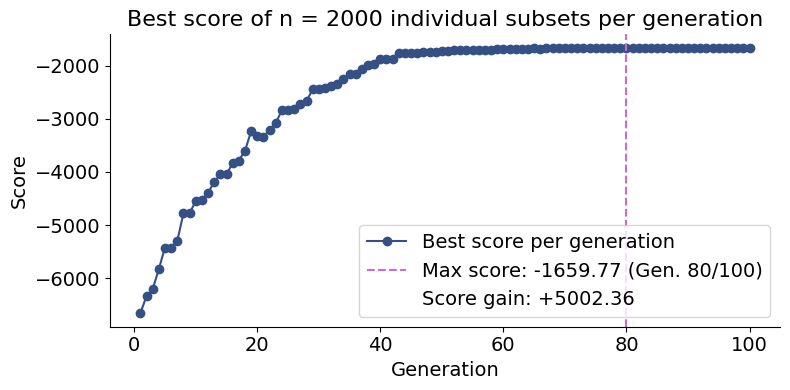

In [15]:
# Plot best fitness per generation
# Find the best generation and best score
best_gen_idx = np.argmax(best_scores)  # Index of the best generation (0-based)
best_gen = best_gen_idx + 1            # Generation number (1-based)
best_score_value = best_scores[best_gen_idx]
lowest_score_value = min(best_scores)
delta = best_score_value - lowest_score_value
all_fitnesses_array = np.array(fitness_array).T
generations = all_fitnesses_array.shape[1]
populations = all_fitnesses_array.shape[0]

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(best_scores) + 1), best_scores, marker='o', color="#345084", label="Best score per generation")

# Add vertical line at best generation
plt.axvline(x=best_gen, color='#CB6BCEFF', linestyle='--', label=f"Max score: {best_score_value:.2f} (Gen. {best_gen}/{generations})")
# Add vertical line at best generation
plt.axvline(x=1, color='white', linestyle='--', alpha = 0.0, label=f"Score gain: +{delta:.2f}")
# Titles and labels
plt.title(f"Best score of n = {populations} individual subsets per generation", fontsize=16)
plt.xlabel("Generation", fontsize=14)
plt.ylabel("Score", fontsize=14)
#adjust fontsize of tick labels:
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(False)
plt.legend(fontsize=14)
#despine:
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
#save as pdf:
plt.savefig(results_dir / 'ga_best_fitness_per_generation.pdf', bbox_inches='tight', dpi=300)
plt.show()

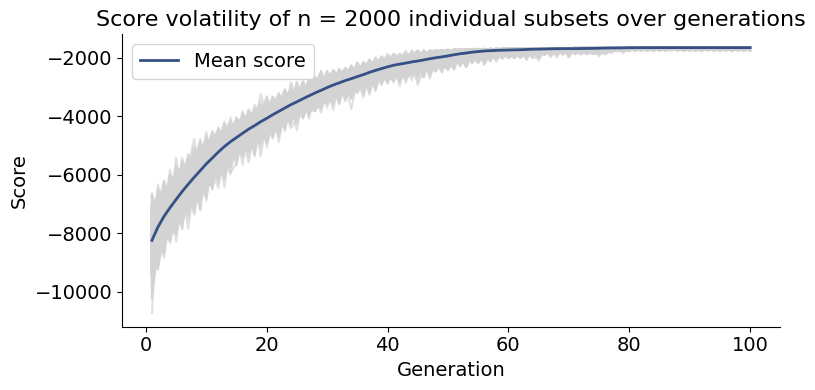

In [16]:
# Plot 2: Fitness volatility over generations
plt.figure(figsize=(8, 4))

all_fitnesses_array = np.array(fitness_array).T

for individual_fitness in all_fitnesses_array:
    plt.plot(range(1, generations + 1), individual_fitness, color='lightgray', alpha=0.7)
mean_fitness = np.mean(all_fitnesses_array, axis=0)
plt.plot(range(1, generations + 1), mean_fitness, color="#345084FF", linewidth=2, label="Mean score")
plt.title(f"Score volatility of n = {populations} individual subsets over generations", fontsize=16)
plt.xlabel("Generation", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()

#save as pdf:
plt.savefig(results_dir / 'ga_fitness_volatility_per_generation.pdf', bbox_inches='tight', dpi=300)
plt.show()   


### Geographic view of the distribution



install geopandas if not already installed in the current env, also contextily for basemaps:

In [32]:
! pip install geopandas
! pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 8.3 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 9.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]
  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mercantile-1.2.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached affine-2.4.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached cligj-0.7.2-py3-none-any.whl.metadata (5.0 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached mercantile-1.2.1-py3-none-any.whl (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 6.3 MB/s eta 0:00:00a 0:00:01
Using cached cligj-0.7.2-py3-none-any.whl (7.1 kB)
Using cached affine-2.4.0-py3-none-any.whl (15 kB)
  Attempting uninstall: click
    Found existing installation: click 8.2.1
    Uninstalling click-8.2.1:
      Successfully uni

In [17]:
#load some colors for plotting
hex_colors2 = ['#240E31FF', '#CB6BCEFF', '#468892FF', '#74F3D3FF',
              '#751C6DFF', '#FDC067FF', '#AC9ECEFF', '#6EC5ABFF']


/var/folders/mn/3_jl7ykj1qd6kmb2tjjqbgt80000gp/T/ipykernel_1947/3039071287.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(groups))


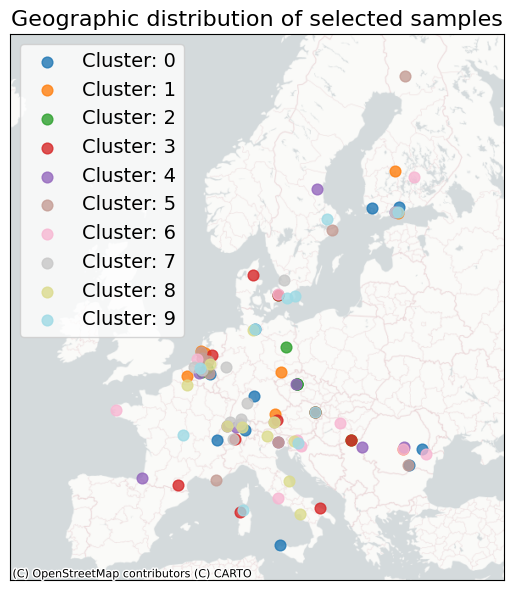

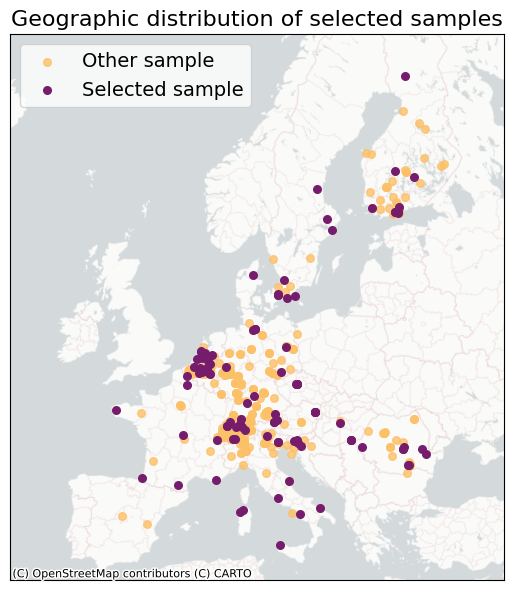

In [18]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as ctx
import numpy as np
from matplotlib import cm

# === CONFIGURE THIS ===
# DataFrame with selected samples, must include columns: Latitude, Longitude, Cluster
df = result_df.copy()

# Rename columns if needed
df = df.rename(columns={'Latitude': 'latitude', 'Longitude': 'longitude'})

# Variable to color by (e.g., 'Cluster' or 'sample_collected')
group_var = 'Cluster'

# === Convert to GeoDataFrame ===
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
geo_df = gpd.GeoDataFrame(df, geometry=geometry)
geo_df = geo_df.set_crs(epsg=4326)  # WGS 84

# Optional: Filter to Europe-ish bounding box
geo_df = geo_df[(geo_df['longitude'] > -50) & (geo_df['longitude'] < 70)]
geo_df = geo_df[(geo_df['latitude'] > 0) & (geo_df['latitude'] < 70)]

# === Assign Colors Dynamically ===
groups = sorted(geo_df[group_var].unique())
cmap = cm.get_cmap('tab20', len(groups))
hex_colors = [mcolors.rgb2hex(cmap(i)[:3]) for i in range(len(groups))]
color_mapping = {grp: hex_colors[i] for i, grp in enumerate(groups)}

# === Convert to Web Mercator for Basemap ===
geo_df = geo_df.to_crs(epsg=3857)

# === Plot ===
fig, ax = plt.subplots(figsize=(8, 6))

for grp in groups:
    sample_data = geo_df[geo_df[group_var] == grp]
    sample_data.plot(
        ax=ax,
        marker='o',
        color=color_mapping[grp],
        alpha=0.8,
        markersize=60,
        label=f"{group_var}: {grp}"
    )
# Set fixed limits (Web Mercator units: meters, not degrees!)
ax.set_xlim([-1700000, 4000000])  # roughly from -20°W to 40°E
ax.set_ylim([4200000, 10500000])   # roughly from 30°N to 65°N
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)


# Formatting
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper left', fontsize=14, title='')
plt.title("Geographic distribution of selected samples", fontsize=16)
ax.set_xticks([])
ax.set_yticks([])
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
#save to pdf:
plt.savefig(results_dir / 'selected_samples_map_by_cluster.pdf', bbox_inches='tight', dpi=300)
plt.show()

df_full = metadata.copy()   # <- all samples
df_selected = result_df.copy()  # <- selected subset

# Make sure columns match
df_full = df_full.rename(columns={'Latitude': 'latitude', 'Longitude': 'longitude'})
df_selected = df_selected.rename(columns={'Latitude': 'latitude', 'Longitude': 'longitude'})

# Add 'Selected' flag
df_full['Selected'] = df_full.index.isin(df_selected.index)

# === Convert to GeoDataFrame ===
geometry = [Point(xy) for xy in zip(df_full['longitude'], df_full['latitude'])]
geo_df = gpd.GeoDataFrame(df_full, geometry=geometry)
geo_df = geo_df.set_crs(epsg=4326)

# Optional: Filter to Europe
geo_df = geo_df[(geo_df['longitude'] > -50) & (geo_df['longitude'] < 70)]
geo_df = geo_df[(geo_df['latitude'] > 0) & (geo_df['latitude'] < 70)]

# Convert to Web Mercator
geo_df = geo_df.to_crs(epsg=3857)

# === Plot ===
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Plot non-selected samples first (background)
geo_df[geo_df['Selected'] == False].plot(
    ax=ax,
    marker='o',
    color=hex_colors2[5],
    markersize=30,
    alpha=0.8,
    label='Other sample'
)
# 2. Plot selected samples on top (foreground)
geo_df[geo_df['Selected'] == True].plot(
    ax=ax,
    marker='o',
    color=hex_colors2[4],
    markersize=30,
    alpha=1.0,
    label='Selected sample'
)

# Set fixed zoom window (Europe)
ax.set_xlim([-1700000, 4000000])
ax.set_ylim([4200000, 10500000])

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)

# Formatting
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper left', fontsize=14, title='')
plt.title("Geographic distribution of selected samples", fontsize=16)
ax.set_xticks([])
ax.set_yticks([])
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
#save to pdf:
plt.savefig(results_dir / 'selected_samples_map_vs_all_samples.pdf', bbox_inches='tight', dpi=300)
plt.show()

### Metadata balance plots
Compare selected vs full dataset for the key metadata fields.


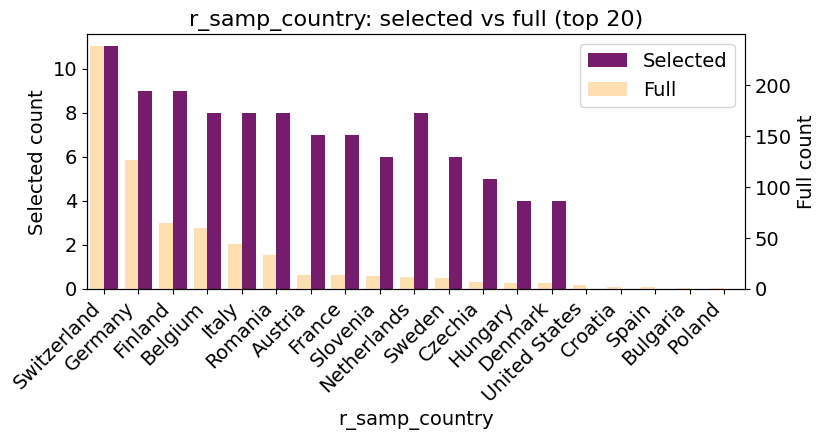

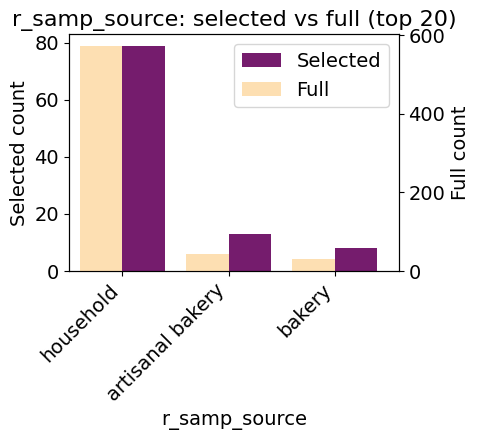

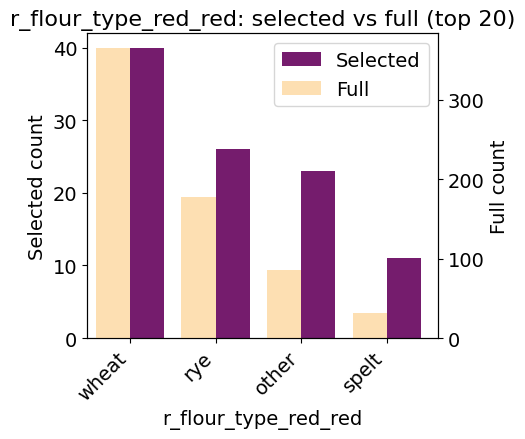

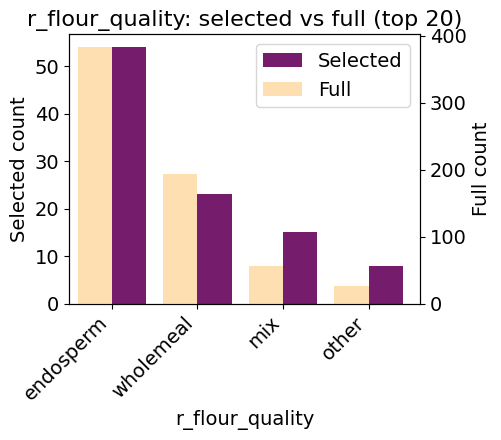

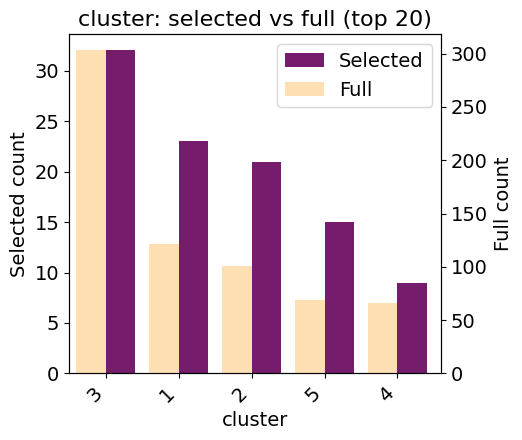

In [19]:
# Python
def plot_category_balance(full_df, selected_df, col, top_n=20):
    import matplotlib.pyplot as plt
    full_counts = full_df[col].value_counts().head(top_n)
    selected_counts = selected_df[col].value_counts().reindex(full_counts.index).fillna(0)
    plot_df = pd.DataFrame({
        'full': full_counts,
        'selected': selected_counts,
    })
    n_categories = len(full_counts.index)
    fig_width = 4 + n_categories * 0.25
    fig, ax1 = plt.subplots(figsize=(fig_width, 4.5))    
    # fig, ax1 = plt.subplots(figsize=(9, fig_width)) 
    plot_df['selected'].plot(kind='bar', ax=ax1, color=hex_colors2[4], position=0, width=0.4, label='Selected')
    ax1.set_ylabel('Selected count', fontsize=14)
    #also make x label larger:
    ax1.set_xlabel(col, fontsize=14)
    ax1.set_xticklabels(plot_df.index, rotation=45, ha='right', fontsize=14)
    ax1.tick_params(axis='y', labelsize=14)

    ax2 = ax1.twinx()
    plot_df['full'].plot(kind='bar', ax=ax2, color=hex_colors2[5], position=1, width=0.4, label='Full', alpha=0.5)
    ax2.set_ylabel('Full count', fontsize=14)
    ax2.tick_params(axis='y', labelsize=14)

    ax1.set_title(f'{col}: selected vs full (top {top_n})', fontsize=16)
    fig.tight_layout()
    plt.subplots_adjust(right=0.85)  # Add more space on the right
    #add legends
    #combine the legends from both axes:
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right', fontsize=14)
    n = len(plot_df.index)
    ax1.set_xlim(-0.5, n - 0.5 + 0.1)  # small extra padding on the right
    ax2.set_xlim(ax1.get_xlim())       # keep both axes aligned
    ax1.margins(x=0.03)
    ax2.margins(x=0.03)

    #save to pdf:
    plt.savefig(results_dir / f'category_balance_{col}.pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Usage:
for col in balance_vars:
    plot_category_balance(metadata, result_df, col, top_n=20)


## Interpreting outputs
- `distance.tsv`: sample-sample distances used by all downstream steps
- `k_diagnostics.tsv` + plot: helps choose k
- `kmedoids_clusters.tsv`: cluster assignments and medoid flags
- `ga_selected_samples.tsv`: final subset with metadata and cluster label
- `ga_best_scores.tsv` + `ga_fitness_array.tsv`: GA convergence diagnostics
